# Comentário adicionado automaticamente

Este é um comentário inserido no início do notebook.

# Aula 1 - Introdução a Inteligência Artificial e a Visão Computacional

# Introdução ao Google Colab

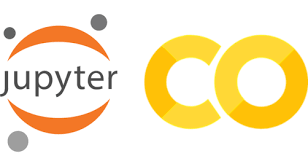

O Google Colaboratory, carinhosamente chamado de Colab, é um serviço de nuvem gratuito hospedado pelo próprio Google para incentivar a pesquisa de Aprendizado de Máquina e Inteligência Artificial.

É uma ferramenta que permite que você misture código fonte (geralmente em python) e texto rico (geralmente em markdown) com imagens e o resultado desse código, uma técnica conhecida como: notebook (“caderno”, em português).

## Quais as vantagens de usar o Google Colab?

O Colaboratory é um serviço bastante útil tanto para estudantes quanto para pessoas pesquisadoras, já que traz diversas funcionalidades e vantagens. Veja a seguir algumas das principais.

Apesar de ser possível testá-lo online, para usar um software como o Jupyter Notebook é necessário fazer o download da aplicação e instalá-la em sua máquina para aproveitar seus recursos da melhor forma. Além disso, você pode ter que fazer configurações complicadas até conseguir deixar o software da maneira que precisa.

Com o Google Colab não existe esse problema, pois não é preciso instalar o Python e nenhum outro software em sua máquina. Ele já é pré-configurado e você pode começar a usá-lo de forma instantânea, o que ajuda a poupar tempo e evita erros.

## Já conta com bibliotecas pré-instaladas

Um dos grandes diferenciais do Python é a sua enorme variedade de bibliotecas que são úteis para diversos tipos de aplicações. No Google Colab, várias delas já vem pré-instaladas, o que torna fácil importá-las e aproveitar seus recursos.

Bibliotecas como Numpy, Pandas, Matplotlib e TensorFlow estão disponíveis, o que já é suficiente para muitas pessoas programadoras. Porém, você não está limitado a isso, já que é possível instalar outras bibliotecas que não estejam disponíveis por padrão.

## Facilita o compartilhamento de código

Para as pessoas programadoras, o trabalho em equipe e o compartilhamento de conhecimentos é algo importante. Com o Google Colab, disponibilizar o seu código para outras pessoas visualizarem ou editarem é algo bem simples.

Ele permite que você baixe notebooks públicos e privados diretamente do GitHub para usá-los na sua conta, ou enviar os notebooks que você criou para o GitHub. Como os notebooks também são salvos na nuvem do Google, você pode compartilhá-los diretamente do seu Drive.

## Permite utilizar recursos computacionais gratuitamente

Uma das maiores vantagens do Google Colab é a possibilidade de usar o hardware de qualidade disponibilizado pelos servidores da Google. O serviço permite inclusive habilitar a opção de utilizar Unidades de Processamento Gráfico (GPUs) na hora de executar os códigos. Isso é útil para quem deseja usar a famosa biblioteca de aprendizado de máquina TensorFlow, por exemplo.

O uso das GPUs e demais recursos computacionais é gratuito, porém caso a pessoa programadora deseje ainda mais vantagens pode optar pela versão Pro do serviço. Ela permite executar seus códigos de forma mais rápida com prioridade para uso das GPUs de melhor desempenho e com mais memória RAM para armazenar dados.

## Mapeamento de Vegetação e Solo usando Redes Neurais Artificiais

Link para acesso ao Dataset: https://drive.google.com/drive/folders/1TpsXxJkVj8sZ3hZUmBPxQ3eihwGOoIpq?usp=sharing

Primeiro vamos instalar o rasterio e conectar o Drive:

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 33.9 MB/s eta 0:00:00


### O que este comando faz?

O comando `!pip install rasterio` instala a biblioteca **rasterio** no ambiente do Google Colab. O `!` no início indica que é um comando de terminal (shell), não código Python. **Rasterio** é essencial para ler, escrever e manipular dados raster geoespaciais (imagens de satélite/drone). Sem ela, não conseguiríamos abrir os arquivos `.tif` usados neste tutorial.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Conectando o Google Drive

Aqui importamos `drive` do módulo `google.colab` e executamos `drive.mount('/content/drive')`. Isso monta seu Google Drive pessoal dentro do ambiente do Colab, na pasta `/content/drive`. A partir daí, podemos acessar diretamente os arquivos do Drive (imagens e shapefiles) usando os caminhos de pasta, sem precisar fazer upload manual a cada sessão.


Agora, vamos importar as bibliotecas:

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window
import pandas as pd
import geopandas as gpd
from pylab import rcParams
import matplotlib
rcParams['figure.figsize'] = 18, 16
from sklearn.model_selection import train_test_split
from rasterio.plot import show
from shapely.geometry import box
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### Importando as bibliotecas

Cada `import` traz uma ferramenta específica para o projeto:

- **`os`**: manipulação de caminhos e pastas do sistema.
- **`cv2` (OpenCV)**: processamento de imagens (leitura, conversão, filtros).
- **`matplotlib.pyplot`**: criação de gráficos e visualização de imagens.
- **`numpy`**: computação numérica e manipulação de arrays (matrizes de pixels).
- **`rasterio`**: leitura/escrita de imagens raster georeferenciadas (GeoTIFF).
- **`pandas`**: manipulação de dados em formato de tabela (DataFrames).
- **`geopandas`**: extensão do Pandas para dados geoespaciais (shapefiles).
- **`sklearn.model_selection`, `metrics`**: divisão treino/teste e avaliação do modelo.
- **`tensorflow.keras`**: construção e treinamento da rede neural (deep learning).

Todas essas bibliotecas trabalham juntas: rasterio/geopandas carregam os dados, numpy/pandas organizam, matplotlib exibe, e tensorflow/keras fazem a inteligência artificial.


A imagem e os shapefiles que serão utilizados estão armazenados no Drive. Foram coletados um shapefile de pontos para cada classe que temos.

In [ ]:
path_img = '/content/drive/MyDrive/Datasets/Cana_solo_veg/AOI.tif'
path_classe1 = '/content/drive/MyDrive/Datasets/Cana_solo_veg/Solo.shp'
path_classe2 = '/content/drive/MyDrive/Datasets/Cana_solo_veg/Veg.shp'

### Definindo os caminhos dos arquivos

Criamos variáveis string (`path_img`, `path_classe1`, `path_classe2`) que guardam os caminhos completos dos arquivos dentro do Google Drive.

- **`path_img`**: caminho da imagem raster (`.tif`) que será classificada.
- **`path_classe1`**: caminho do shapefile de pontos da classe **Solo**.
- **`path_classe2`**: caminho do shapefile de pontos da classe **Vegetação**.

Esses shapefiles contêm coordenadas geográficas de amostras coletadas no campo ou em imagens de referência. Eles serão usados para extrair os valores espectrais e treinar o modelo.


In [ ]:
gdf1 = gpd.read_file(path_classe1)
gdf2 = gpd.read_file(path_classe2)

### Lendo os shapefiles

`geopandas.read_file()` abre arquivos shapefile (`.shp`) e os converte em **GeoDataFrames**. Um GeoDataFrame é como uma planilha Excel que tem uma coluna especial chamada `geometry`, onde ficam armazenadas as coordenadas espaciais (pontos, linhas ou polígonos).

Aqui, `gdf1` contém os pontos de amostra da classe Solo, e `gdf2` os da classe Vegetação. Cada linha dessas tabelas representa um ponto no espaço com informações associadas (incluindo a geometria).


<Axes: >

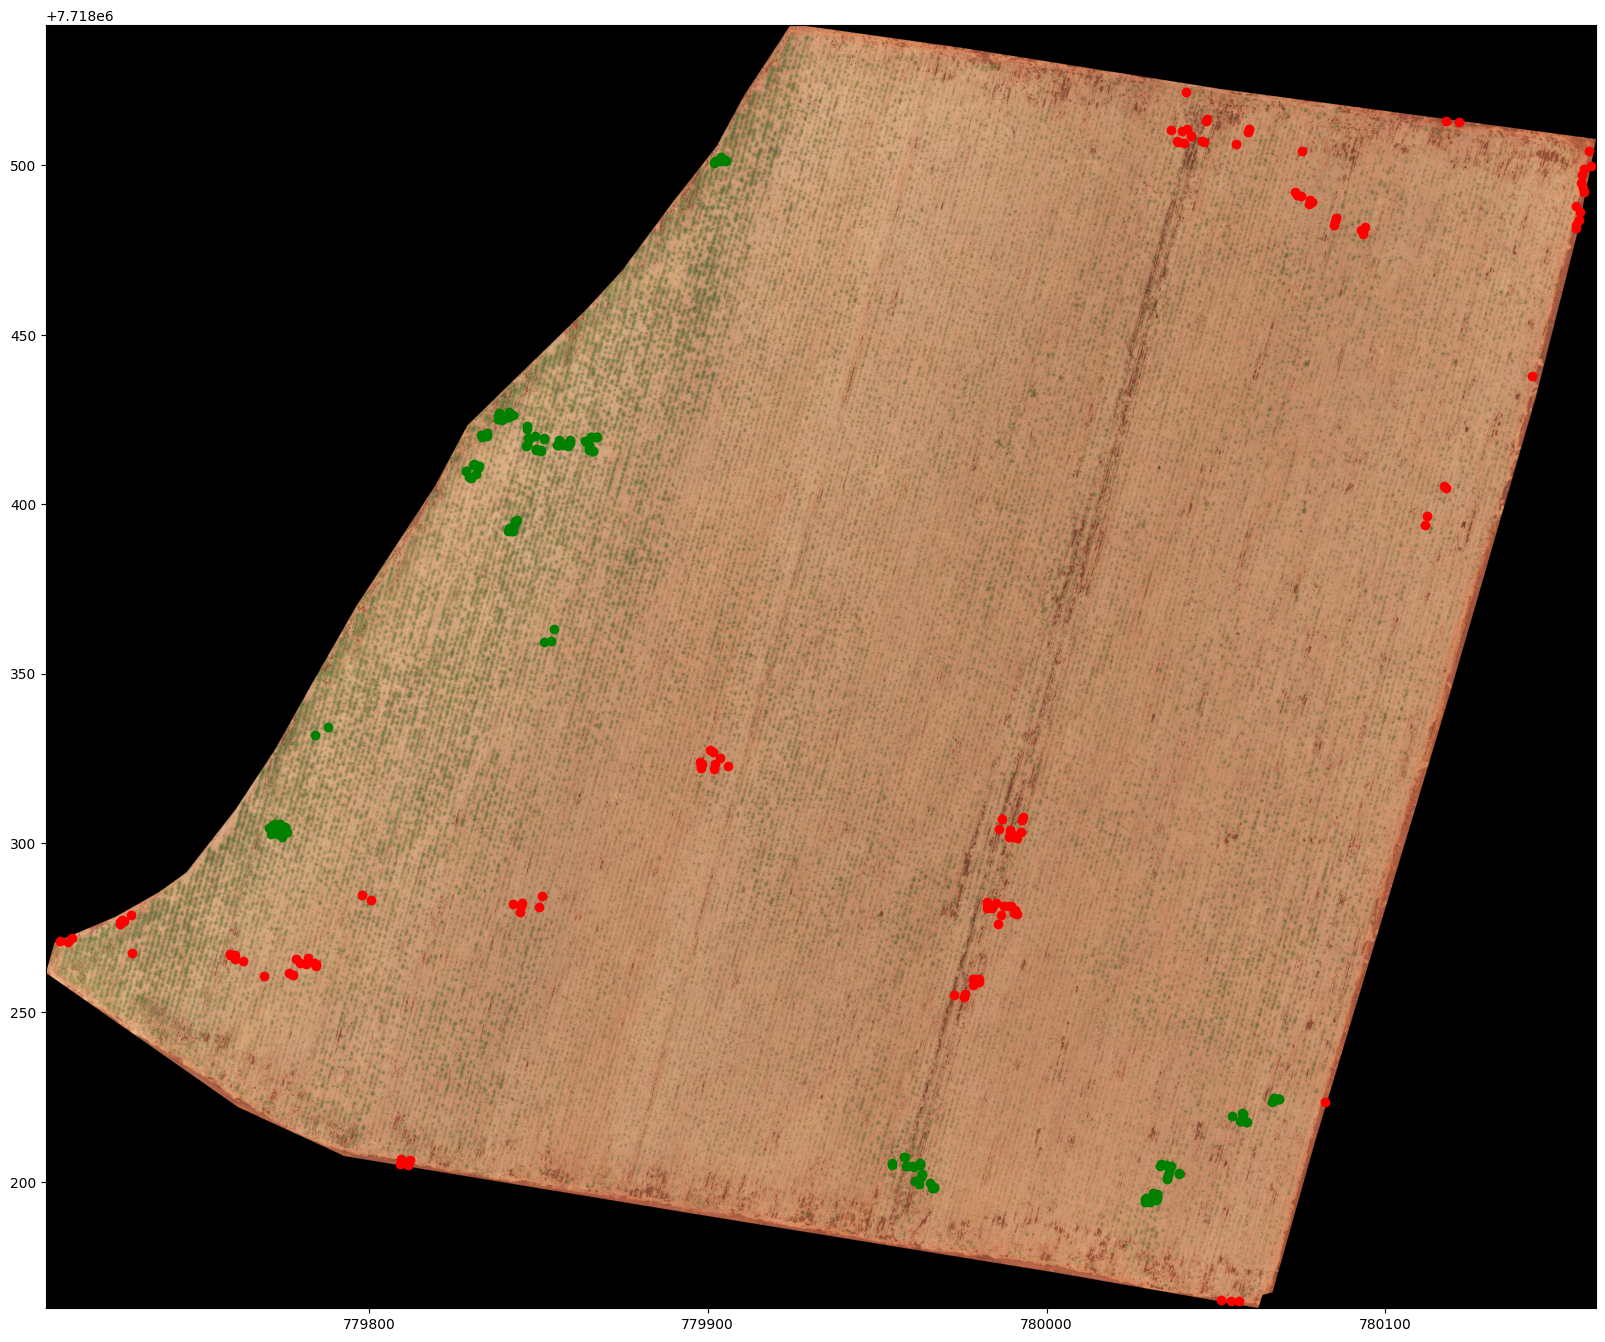

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))
with rasterio.open(path_img) as src:
    gdf1 = gdf1.to_crs(src.crs.to_dict())
    gdf2 = gdf2.to_crs(src.crs.to_dict())
    show(src,ax=ax)
gdf1.plot(ax=ax, color='red')
gdf2.plot(ax=ax, color='green')

### Visualizando a imagem e as amostras

Este trecho cria uma figura com `plt.subplots` e usa `rasterio.plot.show()` para exibir a imagem raster.

Antes de plotar, fazemos `gdf1.to_crs(src.crs.to_dict())` para garantir que os pontos do shapefile estejam no mesmo sistema de coordenadas da imagem. Se os sistemas forem diferentes, os pontos apareceriam deslocados ou em locais errados.

`gdf1.plot(ax=ax, color='red')` desenha os pontos de solo em vermelho e `gdf2.plot(..., color='green')` desenha os pontos de vegetação em verde, sobrepondo à imagem. Isso permite verificar visualmente se as amostras estão no lugar correto antes de treinar o modelo.


Agora adicionamos um id para cada uma das classes:

In [ ]:
gdf1['id'] = 0
gdf2['id'] = 1

### Criando rótulos numéricos (labels)

Modelos de aprendizado de máquina trabalham com números, não com palavras. Por isso, atribuímos:

- **`id = 0`** para a classe **Solo**
- **`id = 1`** para a classe **Vegetação**

Essa coluna `id` será nossa variável de resposta (target) durante o treinamento. O objetivo do modelo é aprender a prever se um pixel é `0` (solo) ou `1` (vegetação) apenas olhando para seus valores espectrais.


In [ ]:
gdf2

,id,geometry
0,1,POINT (779962.447 7718199.437)
1,1,POINT (779965.536 7718199.522)
2,1,POINT (779966.841 7718198.45)
3,1,POINT (779966.661 7718198.269)
4,1,POINT (779966.342 7718198.099)
...,...,...
136,1,POINT (779784.218 7718331.938)
137,1,POINT (779787.933 7718334.167)
138,1,POINT (779851.722 7718359.428)
139,1,POINT (779853.654 7718359.768)


Vamos concatenar os geodataframes de pontos e extrair os valores espectrais da imagem em cada ponto:

In [ ]:
gdf = pd.concat([gdf1,gdf2], axis=0)

### Juntando as amostras

`pd.concat([gdf1, gdf2], axis=0)` empilha (concatena verticalmente) os dois GeoDataFrames em um só. `axis=0` significa que estamos adicionando as linhas de `gdf2` abaixo das linhas de `gdf1`.

O resultado é um único conjunto de dados (`gdf`) com todas as amostras de ambas as classes, pronto para extraímos os valores espectrais correspondentes de cada ponto.


In [ ]:
gdf

,id,geometry
0,0,POINT (779985.798 7718276.003)
1,0,POINT (779986.541 7718278.741)
2,0,POINT (779983.908 7718280.694)
3,0,POINT (779982.56 7718282.101)
4,0,POINT (779982.364 7718282.578)
...,...,...
136,1,POINT (779784.218 7718331.938)
137,1,POINT (779787.933 7718334.167)
138,1,POINT (779851.722 7718359.428)
139,1,POINT (779853.654 7718359.768)


In [ ]:
coord_list = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]

In [ ]:
Values_list = []
Column_list = []
with rasterio.open(path_img) as src:
  Values = [x for x in src.sample(coord_list)]
  Values_list.append(Values)

### Extraindo os valores espectrais

Aqui acontece um passo crucial: para cada ponto de amostra, extraímos os valores das bandas espectrais da imagem naquela coordenada exata.

`coord_list` é uma lista de coordenadas (x, y) de todos os pontos do shapefile combinado. `src.sample(coord_list)` percorre a imagem raster e retorna os valores dos pixels que correspondem a essas coordenadas.

Esses valores são armazenados em `Values_list`, depois convertidos para um array NumPy (`X`). `X` será a **entrada** do nosso modelo de IA (as features/características de cada amostra).


In [ ]:
X = np.array(Values_list)
X = X[0].copy()
X = X[:,0:3].copy()

In [ ]:
X

array([[192, 138, 101],
       [188, 134,  97],
       [134,  69,  52],
       [122,  64,  45],
       [188, 132, 100],
       [192, 134,  95],
       [191, 135, 102],
       [208, 153, 115],
       [188, 142, 102],
       [208, 153, 109],
       [204, 153, 114],
       [116,  53,  42],
       [114,  60,  41],
       [121,  71,  48],
       [123,  65,  48],
       [130,  68,  50],
       [137,  74,  58],
       [189, 128,  94],
       [194, 131,  94],
       [124,  58,  38],
       [178, 119,  87],
       [186, 131,  98],
       [168,  88,  64],
       [145,  83,  57],
       [129,  72,  49],
       [198, 145, 110],
       [203, 151, 109],
       [200, 144, 110],
       [222, 173, 134],
       [202, 153, 112],
       [197, 146, 106],
       [196, 144, 109],
       [192, 141, 102],
       [206, 150, 113],
       [127,  72,  51],
       [207, 154, 118],
       [154, 100,  74],
       [172, 118,  91],
       [122,  63,  49],
       [196, 144, 104],
       [191, 136, 100],
       [192, 138

Agora temos a variável X com os dados espectrais e a vairável Y com os dados de referência:

In [ ]:
Y = gdf['id'].values
Y = Y[:,np.newaxis]

### Separando entrada (X) e saída (Y)

- **`X`**: Array com os valores espectrais de cada ponto (ex: intensidade de Vermelho, Verde, Azul). São os dados que o modelo usará para aprender.
- **`Y`**: Array com os IDs das classes (0 = Solo, 1 = Vegetação). É o que queremos que o modelo preveja.

`Y = Y[:, np.newaxis]` reorganiza o array para ter duas dimensões (uma coluna), o que é necessário para compatibilidade com o formato esperado pelo Keras durante o treinamento.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix

In [ ]:
Y.shape

(272, 1)

Então, dividimos os dados em treinamento e teste:

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

### Dividindo em Treino e Teste

`train_test_split(X, Y, test_size=0.3, random_state=42)` separa nossos dados em dois grupos:

- **Treino (70%)**: `X_train` e `Y_train` — usados para ensinar o modelo.
- **Teste (30%)**: `X_test` e `Y_test` — usados para avaliar o quanto o modelo aprendeu de verdade.

`test_size=0.3` define que 30% dos dados ficam para teste. `random_state=42` fixa a "semente" aleatória, garantindo que, toda vez que rodarmos o código, a divisão seja exatamente a mesma. Isso torna o experimento **reprodutível**.


In [ ]:
input_shape = (X_train.shape[1:])
num_classes = len(np.unique(gdf['id'].values))

### Preparando as dimensões do modelo

`input_shape` define o formato da entrada da rede neural. Como cada amostra em `X` tem várias bandas espectrais, `X_train.shape[1:]` captura esse formato (por exemplo, 3 valores se forem R, G, B).

`num_classes = len(np.unique(gdf['id'].values))` conta quantas classes únicas existem (no caso, 2: solo e vegetação). Isso é útil para definir a camada de saída do modelo.


In [ ]:
input_shape

(3,)

In [ ]:
num_classes

2

Então vamos construir nossa rede neural adicionando as camadas densas:

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(256, input_shape=input_shape, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Construindo a Rede Neural

Usamos `Sequential()` do Keras para criar a arquitetura da rede neural camada por camada:

1. **`Dense(256, input_shape=input_shape, activation='relu')`**:
   - Primeira camada oculta com 256 neurônios.
   - Recebe os dados de entrada com formato definido por `input_shape`.
   - `relu` (Rectified Linear Unit) é uma função de ativação que ajuda a rede a aprender padrões complexos e não-lineares.

2. **`Dense(128, activation='relu')`**, **`Dense(64, ...)`**, **`Dense(8, ...)`**:
   - Camadas ocultas adicionais. A quantidade de neurônios diminui gradualmente,    permitindo que a rede vá refinando as características aprendidas.

3. **`Dense(1, activation='sigmoid')`**:
   - Camada de saída com apenas 1 neurônio.
   - `sigmoid` retorna um valor entre **0 e 1**, ideal para problemas de classificação binária (duas classes).
   - Valores próximos de 0 indicam 'Solo'; próximos de 1 indicam 'Vegetação'.


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### Compilando o modelo

`model.compile(...)` configura como o modelo será treinado:

- **`loss='binary_crossentropy'`**: Função de perda para classificação binária. Ela mede a diferença entre a previsão do modelo e a resposta real (0 ou 1). O objetivo do treino é minimizar esse valor.

- **`optimizer='adam'`**: Algoritmo de otimização que ajusta os pesos da rede neural a cada passo. O Adam é popular porque converge rapidamente e funciona bem na maioria dos casos.

- **`metrics=['accuracy']`**: Durante o treino, queremos monitorar a acurácia (percentual de previsões corretas) para ver se o modelo está melhorando.


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,705 (166.82 KB)

 Trainable params: 42,705 (166.82 KB)

 Non-trainable params: 0 (0.00 B)

E, finalmente, treine o modelo para 100 iterações:

In [ ]:
history = model.fit(X_train, Y_train, epochs=100, batch_size=250, verbose=1, validation_split=0.25)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5282 - loss: 5.3774 - val_accuracy: 0.4167 - val_loss: 1.4501
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4718 - loss: 1.3574 - val_accuracy: 0.4583 - val_loss: 0.6908
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5000 - loss: 0.6858 - val_accuracy: 0.6042 - val_loss: 0.6940
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5423 - loss: 0.9173 - val_accuracy: 0.7083 - val_loss: 0.3966
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6761 - loss: 0.5396 - val_accuracy: 0.8542 - val_loss: 0.3223
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7958 - loss: 0.3490 - val_accuracy: 0.8750 - val_loss: 0.3117
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7958 - loss: 0.3523 - val_accuracy: 0.7917 - val_loss: 0.3966
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6972 - loss: 0.6515 - val_accuracy: 0.9792 - val_loss: 0

### Treinando o modelo

`model.fit(...)` inicia o processo de aprendizado da rede neural:

- **`epochs=100`**: O modelo passará por todo o conjunto de treino 100 vezes. Cada passagem completa é chamada de época.
- **`batch_size=250`**: Os dados são processados em lotes de 250 amostras por vez. Isso equilibra velocidade e estabilidade do treinamento.
- **`validation_split=0.25`**: 25% dos dados de treino são separados internamente para validação. Isso permite acompanhar se o modelo está melhorando em dados que não estão sendo usados diretamente no ajuste dos pesos.

Durante esse processo, o modelo ajusta milhares de parâmetros (pesos e biases) para encontrar a melhor forma de separar solo de vegetação com base nos dados espectrais.


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(16,8))
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

### Analisando os gráficos de treinamento

Esses gráficos mostram a evolução do treino ao longo das épocas:

**Gráfico da Esquerda (Loss / Perda):**
- `Training loss` (azul): erro do modelo nos dados de treino. Deve diminuir com o tempo.
- `Validation loss` (vermelho): erro nos dados de validação. Se subir enquanto o treino continua descendo, é sinal de **overfitting** (o modelo está 'decorando' os dados em vez de generalizar).

**Gráfico da Direita (Accuracy / Acurácia):**
- Mostra a porcentagem de acertos. Quanto mais próximo de 1.0 (100%), melhor.
- Uma grande diferença entre `Training accuracy` e `Validation accuracy` também indica overfitting.


Vamos ver algumas métricas de avaliação do modelo:

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.02030148357152939
Test accuracy: 0.9878048896789551


### Avaliação final do modelo

Após o treino, usamos dados que o modelo **nunca viu** (`X_test`, `Y_test`) para medir o desempenho real:

- **`model.evaluate(...)`**: Retorna a perda final e a acurácia no conjunto de teste.
- **`classification_report`**: Mostra métricas detalhadas para cada classe:
  - **Precision**: das vezes que o modelo previu uma classe, quantas estavam certas?
  - **Recall**: de todas as amostras reais de uma classe, quantas o modelo encontrou?
  - **F1-Score**: média harmônica entre Precision e Recall.
- **`confusion_matrix`**: Tabela que mostra quantas amostras de cada classe foram classificadas corretamente e quantas foram confundidas com a outra classe.


In [ ]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [ ]:
y_pred = np.round(y_pred)

In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.97      1.00      0.99        38

    accuracy                           0.99        82
   macro avg       0.99      0.99      0.99        82
weighted avg       0.99      0.99      0.99        82



In [ ]:
c_matrix = confusion_matrix(Y_test, y_pred)

In [ ]:
names = ['Solo','Vegetação']

Text(0.5, 58.7222222222222, 'Predict')

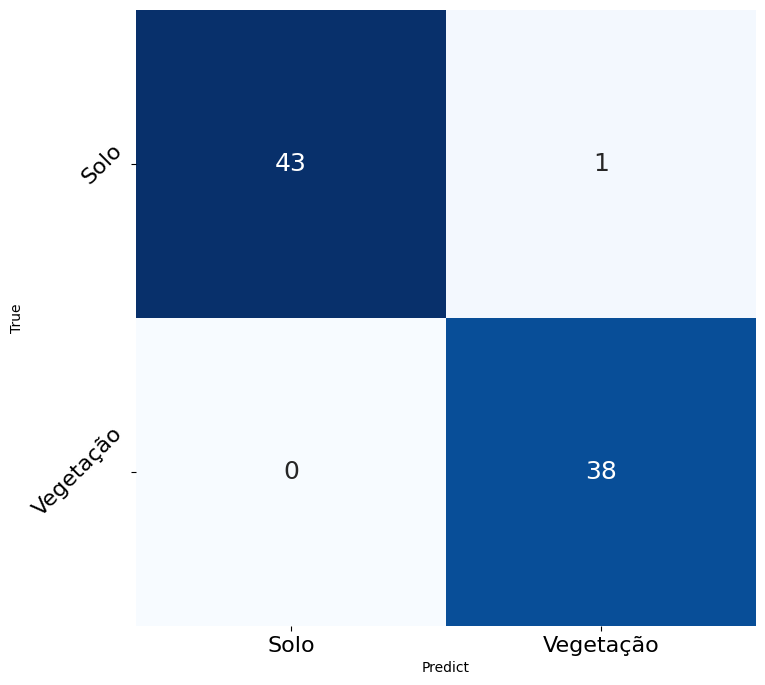

In [ ]:
r1 = pd.DataFrame(data=c_matrix, index= names, columns=names)
fig, ax = plt.subplots(figsize=(8,8))
ax = sns.heatmap(r1, annot=True, annot_kws={"size": 18},fmt='d',cmap="Blues", cbar = False)
ax.tick_params(labelsize=16)
ax.set_yticklabels(names, rotation=45)
ax.set_ylabel('True')
ax.set_xlabel('Predict')

Após treinar e validar nosso modelo de IA, vamos agora aplicar à imagem completa, gerando assim uma mapa com as predições:

In [ ]:
path_img_test = '/content/drive/MyDrive/Datasets/Cana_solo_veg/AOI_test.tif'
src = rasterio.open(path_img_test)
img = src.read()

### Preparando a imagem de teste

Agora aplicamos o modelo treinado em uma imagem completa (`AOI_test.tif`).

`src.read()` carrega todas as bandas da imagem. O formato original é `(bandas, altura, largura)`.
`transpose([1,2,0])` reorganiza para `(altura, largura, bandas)`, que é mais fácil de manipular.

`reshape(...)` achata a imagem em um array 2D onde cada linha é um pixel e cada coluna é uma banda. Isso é necessário porque o modelo espera receber os dados nesse formato para fazer as previsões.


In [ ]:
img = img.transpose([1,2,0])
img_size = (img.shape[0] , img.shape[1])
img = img.reshape(img.shape[0] * img.shape[1], img.shape[2])

In [ ]:
img.shape

(139480677, 4)

Depois de abrir a imagem, vamos criar um dataframe com as informações espectrais e a banda alfa:

In [ ]:
df = pd.DataFrame(img, columns=['R','G','B','Mask'])

### Criando o DataFrame de pixels

Convertemos o array de pixels em um **DataFrame do Pandas** com colunas nomeadas: `R`, `G`, `B` e `Mask`.

- **R, G, B**: valores das bandas espectrais (Vermelho, Verde, Azul).
- **Mask**: banda alfa/máscara que indica se o pixel é válido (geralmente 255 = válido, 0 = inválido/sem dados).

Depois, removemos os pixels inválidos (`df['Mask'] != 255`) para que o modelo não faça previsões em áreas sem dados.


In [ ]:
del img, src

Removeremos os valores não-validos usando a banda alfa:

In [ ]:
df_to_pred = df[df['Mask'] == 255].copy()
values_to_pred = df_to_pred.values[:,0:3]

### Filtrando pixels válidos

`df_to_pred = df[df['Mask'] == 255].copy()` seleciona apenas os pixels onde a máscara indica valor válido (255). Isso remove bordas, nuvens ou áreas sem informação.

`values_to_pred = df_to_pred.values[:,0:3]` extrai apenas as colunas R, G, B (as 3 primeiras colunas) para alimentar o modelo. A coluna Mask não é mais necessária para a predição.


In [ ]:
df_to_pred.drop(columns={'R', 'G', 'B'}, inplace = True)
df.drop(columns={'R', 'G', 'B'}, inplace = True)

Agora aplicamos o modelo nos valores para obter as predições:

In [ ]:
pred = model.predict(values_to_pred)

2377001/2377001 [==============================] - 2856s 1ms/step


### Fazendo as previsões

`model.predict(values_to_pred)` passa todos os pixels válidos pela rede neural treinada. O modelo retorna um valor entre 0 e 1 para cada pixel.

`np.round(pred)` arredonda esses valores para 0 ou 1, transformando a saída em uma classificação definitiva:
- **0** = Solo
- **1** = Vegetação


Com os valores preditos, unimos ao dataframe da imagem completo pelo indice:

In [ ]:
pred = np.round(pred).copy()
df_to_pred['pred'] = pred

In [ ]:
del pred, values_to_pred, model

In [ ]:
df = pd.merge(df,df_to_pred, how='left', left_index=True, right_index=True)

### Reunindo as previsões com a imagem completa

`pd.merge(df, df_to_pred, ...)` junta as previsões de volta ao DataFrame original (`df`) usando os índices dos pixels. Assim, cada pixel válido recebe seu valor predito (0 ou 1).

Pixels inválidos (que foram removidos anteriormente) ficarão sem valor (`NaN`).


In [ ]:
del df_to_pred

Assim temos as predições e podemos converter para o tamanho da imagem original::

In [ ]:
values_to_export = df['pred'].values

In [ ]:
del df

In [ ]:
classify = values_to_export.reshape(img_size)
export_image = classify[np.newaxis,:,:]

### Reorganizando para o formato da imagem

`values_to_export.reshape(img_size)` converte o array de previsões de volta para as dimensões espaciais originais da imagem (altura × largura). 

`export_image = classify[np.newaxis, :, :]` adiciona uma dimensão extra para compatibilidade com o formato esperado pelo rasterio ao salvar (1 banda, altura, largura).


Por fim salvamos os dados da imagem predita com o georreferenciamento da imagem RGB usada:

In [ ]:
export_image.dtype

dtype('float32')

In [ ]:
src = rasterio.open(path_img)
out_meta = src.meta.copy()
out_meta.update({"driver": "GTiff",
                  "height": export_image.shape[1],
                  "width": export_image.shape[2],
                  "compress":'lzw',
                  "nodata": np.nan,
                  "dtype": 'float64',
                  "count":1
                  })

### Salvando o mapa classificado

Finalmente, salvamos o resultado como um novo arquivo GeoTIFF (`mapa.tif`).

`out_meta = src.meta.copy()` copia os metadados da imagem original (sistema de coordenadas, tamanho do pixel, etc.).
Atualizamos alguns campos como `driver`, `height`, `width`, `dtype`, `count` e `nodata`.

`rasterio.open(..., 'w', **out_meta)` abre um novo arquivo para escrita e `dest.write(export_image)` grava a banda classificada. O arquivo resultante pode ser aberto em qualquer software GIS (QGIS, ArcGIS, etc.).


In [ ]:
with rasterio.open('/content/mapa.tif', "w", **out_meta) as dest:
     dest.write(export_image)

### Salvando o mapa classificado

Finalmente, salvamos o resultado como um novo arquivo GeoTIFF (`mapa.tif`).

`out_meta = src.meta.copy()` copia os metadados da imagem original (sistema de coordenadas, tamanho do pixel, etc.).
Atualizamos alguns campos como `driver`, `height`, `width`, `dtype`, `count` e `nodata`.

`rasterio.open(..., 'w', **out_meta)` abre um novo arquivo para escrita e `dest.write(export_image)` grava a banda classificada. O arquivo resultante pode ser aberto em qualquer software GIS (QGIS, ArcGIS, etc.).


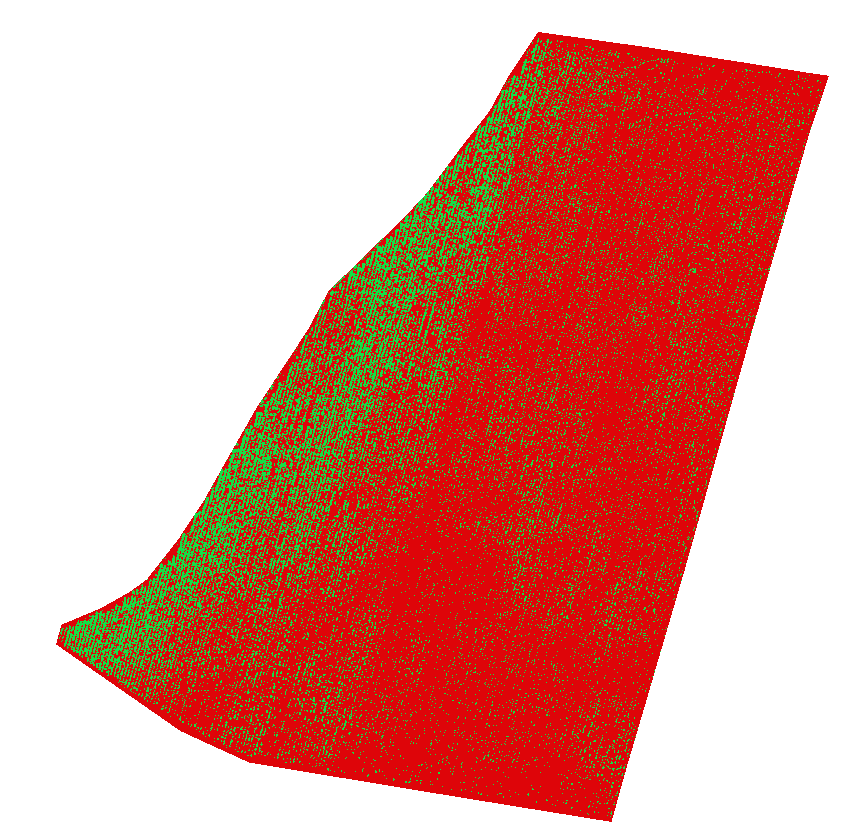

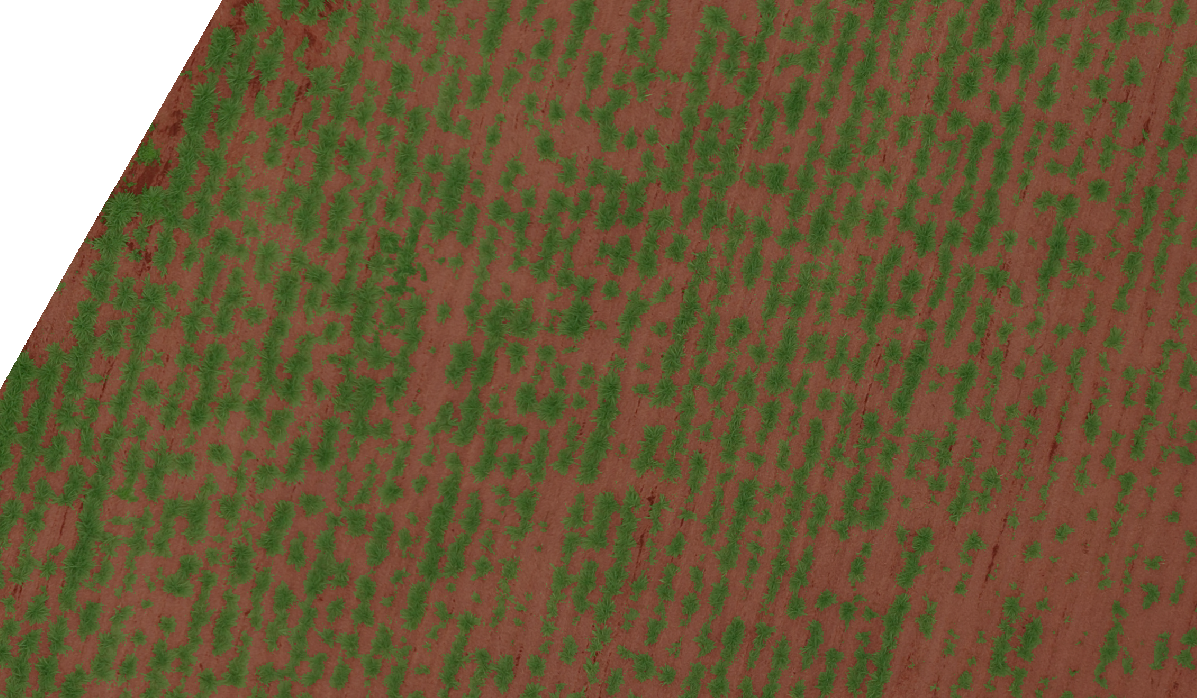